# Clamped beam with the common MORFE API

This conservative St. Venant–Kirchhoff example uses only the public, physics-independent MORFE workflow. It builds a reduced-order model of the first bending mode and reads the **backbone curve** off it: the amplitude-dependent oscillation frequency, which no linear spectrum can give.

Before the first run, initialise the example environment from the MORFEFerrite repository root with `julia --project=examples/01_clamped_beam_ferrite -e 'using Pkg; Pkg.develop(path="."); Pkg.instantiate()'`. This selects MORFEFerrite from the current checkout and downloads MORFE from Julia's package registry.

The first cell activates and instantiates that environment. `SVK` is only a short name for the structural backend used to describe the mechanical case; `build_model` and `parametrise` belong to the common API.

In [1]:
import Pkg
Pkg.activate(@__DIR__; io = devnull)
Pkg.instantiate(; io = devnull)
using MORFE, MORFEFerrite
const SVK = MORFEFerrite.StructuralSVK # for Saint-Venant-Kirchhoff hyperelasticity

┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Pkg/src/API.jl:1322


MORFEFerrite.StructuralSVK

## 1. Describe the mechanical case

`order` is the polynomial expansion order. Order 9 is the reference calculation and costs about 35 seconds of solve; the whole notebook runs in under a minute. Because the cohomological solve is **graded**, a degree-`N` coefficient never depends on a higher degree, so orders 3, 5 and 7 are exact truncations of this one solve rather than three more runs.

`mechanical_model` reads the mesh and supplies the physical information required by the structural backend. Here the Rayleigh damping coefficients are zero, so the beam is conservative. `dirichlet = "Dirichlet"` names a physical facet group stored in the Gmsh mesh; every displacement component on those labeled facets is fixed to zero, producing the clamped ends. The finite-element and quadrature orders use their API defaults.

In [2]:
order = 9
case = SVK.mechanical_model(joinpath(@__DIR__, "clamped_clamped_beam.msh");
    material = SVK.SVKMaterial(E = 160e3, ν = 0.22, ρ = 2.32e-3),
    damping = SVK.RayleighDamping(α = 0.0, β = 0.0),
    dirichlet = "Dirichlet")

Info    : Reading '/Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/01_clamped_beam_ferrite/clamped_clamped_beam.msh'...
Info    : 27 entities
Info    : 328 nodes
Info    : 270 elements
Info    : Done reading '/Users/tiago/Desktop/AM-TUM/Code/MORFEFerrite/MORFEFerrite.jl/examples/01_clamped_beam_ferrite/clamped_clamped_beam.msh'


AssembledMechanicalModel (Ferrite)
  free DOFs : 4977 (of 5103)
  material  : SVK  E=160000.0  ν=0.22  ρ=0.00232
  damping   : Rayleigh  α=0.0  β=0.0

## 2. Build the MORFE model

`build_model` converts the structural case into MORFE's physics-independent model and computes its spectral data. `master = [1]` selects the first vibration-mode pair as the tangent space of the reduced model. The returned `meta` contains auxiliary backend information, including the selected eigenvalues displayed below.

In [3]:
(; model, spectral, meta) = build_model(case; master = [1], expansion_order = order)
meta.spectrum.eigenvalues[meta.master_indices] # print master eigenvalues

2-element Vector{ComplexF64}:
  0.0 + 0.5374120526400513im
 -0.0 - 0.5374120526400513im

## 3. Parametrise the invariant manifold

`parametrise` computes the polynomial manifold map `W` and its reduced dynamics `R` up to the chosen order. The resonance configuration keeps near-resonant monomials in complex normal form. Evaluating `R` at the end of the cell displays the reduced system.

In [4]:
W, R = parametrise(model, spectral, order;
    resonance = ResonanceConfig(style = :complex_normal_form, tol = 0.05))
R # print reduced dynamics

┌ Warning: Monomials are near-resonant with outer physical mode pair 6 (spectrum entries 11, 12; λ = 0.000e+00 ± 4.793e+00i). That mode is not on the manifold, so its direction is solved through a near-singular operator and the ROM will lose accuracy there regardless of how the load is shaped. Offending monomial exponents: (9, 0), (0, 9). Add mode 6 to the master set, detune the forcing, or add damping.
└ @ MORFE.Resonance ~/Desktop/AM-TUM/Code/MORFE_jl/src/ParametrisationMethod/Resonance.jl:1174
┌ Info: conjugate_permutation is active — the following assumptions must hold:
│   1. Real-valued FOM: all matrices in model.linear_terms and all nonlinear/force terms must have real-valued entries (eltype <: Real or purely-real complex).
│   2. Each mode either comes in a complex conjugate pair with another mode, or is self-paired  meaning it has a real eigenvalue and a real-valued mode shape.
│   3. Eigenvalue conjugacy is necessary but NOT sufficient for paired modes; the right eigenvectors

┌ Info: Using optimised FEM path: cached per-element loop
└   n_fem_terms = 2


ReducedDynamics{2, 2, ComplexF64}(DensePolynomial{ComplexF64, 2, 2, Matrix{ComplexF64}}(ComplexF64[0.0 + 0.5374120526400513im 0.0 + 0.0im … 0.0 - 0.0im 0.0 - 0.0im; 0.0 + 0.0im -0.0 - 0.5374120526400513im … 0.0 - 0.0im 0.0 - 0.0im], MultiindexSet{2}(StaticArraysCore.SVector{2, Int64}[[1, 0], [0, 1], [2, 0], [1, 1], [0, 2], [3, 0], [2, 1], [1, 2], [0, 3], [4, 0]  …  [9, 0], [8, 1], [7, 2], [6, 3], [5, 4], [4, 5], [3, 6], [2, 7], [1, 8], [0, 9]], [0, 0, 2, 5, 9, 14, 20, 27, 35, 44, 54]), [9, 9]), 0)

## 4. Read the backbone off R

In normal form the orbit is a circle $z_1 = \rho e^{i\Omega t}$. Every surviving monomial has $a - b = 1$, so substituting it gives every term of $R_1$ the same factor $e^{i\theta}$ and the phase drops out. Matching $\dot z_1 = (\dot\rho + i\rho\dot\theta)e^{i\theta}$ against it separates amplitude from phase:

$$\dot\rho = \mathrm{Re}\,R_1(\rho, \rho) \qquad\qquad \Omega = \frac{\mathrm{Im}\,R_1(\rho, \rho)}{\rho}$$

The beam is conservative, so $\mathrm{Re}\,R_1 \equiv 0$: every amplitude is a periodic orbit, and $\Omega$ is an explicit polynomial in $\rho$. That polynomial is the backbone, and `normal_form_branch` evaluates it.

$\rho$ is a coordinate on the manifold, not a length. `observable_polynomial` projects `W` onto one degree of freedom to recover a physical displacement, and `cycle_amplitude` reads its half peak-to-peak excursion over one cycle. Node 289 sits at mid-span on the top surface, where the first bending mode peaks.

In [5]:
u = observable_polynomial(W, SVK.probe_dof(case, 289, 2)) # y displacement at mid-span

thickness = 10.0                  # beam thickness, mesh length units
ρ = range(0, 85; length = 341)    # modal amplitude; ρ = 85 is ≈ 1.1 × thickness at the probe
ω₀ = normal_form_branch(R; amplitudes = [0.0]).frequency[1]

curves = map(3:2:order) do N
    b = normal_form_branch(restrict_ReducedDynamics_to_degree(R, N); amplitudes = ρ)
    P = MORFE.Polynomials.restrict_polynomial_to_degree(u, N)
    (; N, b.amplitude, b.frequency, dω = 100 .* (b.frequency ./ ω₀ .- 1),
        a = cycle_amplitude.(Ref(P), b.amplitude) ./ thickness)
end

4-element Vector{@NamedTuple{N::Int64, amplitude::Vector{Float64}, frequency::Vector{Float64}, dω::Vector{Float64}, a::Vector{Float64}}}:
 (N = 3, amplitude = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25  …  82.75, 83.0, 83.25, 83.5, 83.75, 84.0, 84.25, 84.5, 84.75, 85.0], frequency = [0.5374120526400513, 0.5374135823492271, 0.5374181714767545, 0.5374258200226336, 0.5374365279868644, 0.5374502953694467, 0.5374671221703806, 0.5374870083896662, 0.5375099540273034, 0.5375359590832923  …  0.7050085196514555, 0.7060227168350204, 0.707039973436937, 0.7080602894572052, 0.7090836648958251, 0.7101100997527965, 0.7111395940281197, 0.7121721477217944, 0.7132077608338208, 0.7142464333641987], dω = [0.0, 0.00028464363019953254, 0.0011385745208203346, 0.0025617926718624062, 0.004554298083347952, 0.007116090755210358, 0.010247170687516238, 0.013947537880243388, 0.0182171923333474, 0.023056134046917087  …  31.185840769309504, 31.374559496137945, 31.56384751022683, 31.75370481157611, 31.94413

## 5. Plot the backbone

The beam stiffens as it swings: at a displacement of about three quarters of its thickness the frequency has risen roughly 13 % above the linear eigenfrequency. Plotting the four truncations together shows where the expansion stops converging, which is the honest way to read the useful range of a ROM. They agree near the origin and separate as the amplitude grows.

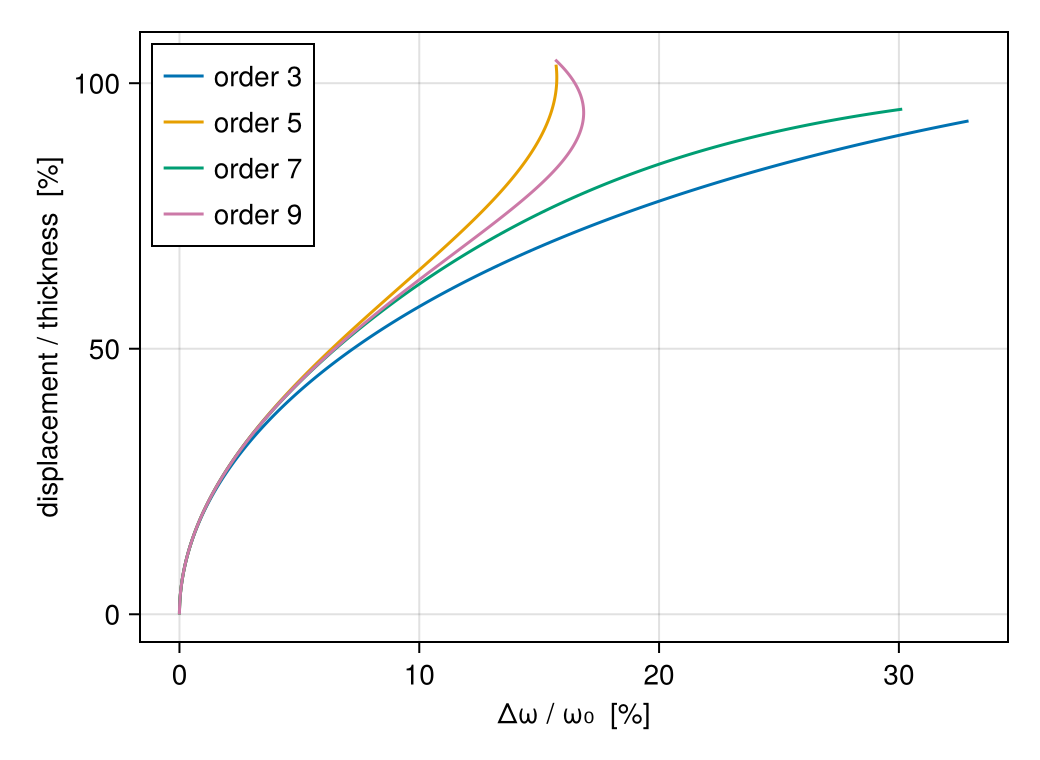

In [6]:
using CairoMakie
fig = Figure(size = (520, 380))
ax = Axis(fig[1, 1]; xlabel = "Δω / ω₀  [%]", ylabel = "displacement / thickness  [%]")
foreach(c -> lines!(ax, c.dω, 100 .* c.a; label = "order $(c.N)"), curves)
axislegend(ax; position = :lt)
fig

## 6. Save the ROM and the backbone

The common saver writes `W`, `R`, their coefficient table and a summary to the example's `results` directory. `drop_below = 0.0` keeps every coefficient: the degree-9 resonant term is of order `1e-17`, and the default cut of `1e-14` would discard the very row the reference is blessed on.

The two CSVs alongside it are the backbone this notebook computed and the probe row of `W` it was computed from. The first is the data the MORFE website's backbone figure draws; the second is what makes that figure reproducible, since `W.jls` is not committed.

In [7]:
MORFE.save_rom(joinpath(@__DIR__, "results"), W, R; drop_below = 0.0)

open(joinpath(@__DIR__, "results", "data", "backbone.csv"), "w") do io
    println(io, "order,r,omega,omega_ratio,amplitude,amplitude_ratio")
    for c in curves, i in eachindex(c.amplitude)
        println(io, join((c.N, c.amplitude[i], c.frequency[i], c.frequency[i] / ω₀,
            thickness * c.a[i], c.a[i]), ","))
    end
end

open(joinpath(@__DIR__, "results", "data", "W_probe_coefficients.csv"), "w") do io
    println(io, "exp_1,exp_2,W_y_re,W_y_im")
    for (e, c) in zip(MORFE.Polynomials.multiindex_set(u).exponents,
        MORFE.Polynomials.coefficients(u))
        println(io, join((e[1], e[2], real(c), imag(c)), ","))
    end
end